Accuracy: 0.61

Classification Report:
               precision    recall  f1-score   support

           1       0.70      0.66      0.68       140
           2       0.47      0.54      0.50        50
           3       0.57      0.57      0.57       105

    accuracy                           0.61       295
   macro avg       0.58      0.59      0.58       295
weighted avg       0.61      0.61      0.61       295



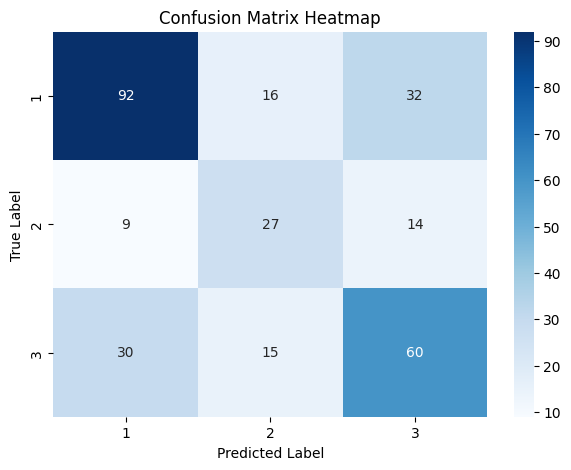

In [1]:
from sys import stdin
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Calcularea prob gausiene pentru predictie
def GaussProbabilityCalc(x, mean, std):
    exponent = np.exp( -((x - mean)**2) / (2 * (std**2)) )
    return (1 / (np.sqrt(2 * np.pi) * std)) * exponent

def build_naive_bayes_model(X, y, numerical_features):
  #Modelul este creat ca dictionar cu feature ca chei
    model = {}
    #Class counts retine de cate ori apare fiecare clasa in setul de train
    class_counts = y.value_counts()
    total_samples = len(y)
    # Se calculeaza probabilitatea pentru fiecare dintre cele 3 clase pe baza value_counts din setul de date
    #Tot dictionar
    class_priors = {cls: count / total_samples for cls, count in class_counts.items()}

    # Pentru fiecare coloana din X adica feature-urile se verifica daca este coloana de tip numeric sau alt tip (Bool/Categorical)
    #pe baza listei de intrare si se calculeaza fie media si deviata standard fie probabilitatea valorii
    for feature in X.columns:
        if feature in numerical_features:
            stats = { #Selecteza randurile care au cls egala cu y (clasa de iesire este cea din cls) si face media pt fiecare din acestea
                cls: {
                    "mean": X.loc[y == cls, feature].mean(),
                    "std": X.loc[y == cls, feature].std()
                } for cls in class_priors.keys()
            }
            model[feature] = stats
        else:
            probs = { #Selecteza randurile care au cls egala cu y (clasa de iesire este cea din cls) si compara daca valorile din feature sunt cele din value sum/nr. de var de cls resp
                value: {
                    cls: (X.loc[y == cls, feature] == value).sum() / class_counts[cls]
                    for cls in class_priors.keys()
                } for value in X[feature].unique()
            }
            model[feature] = probs

    #Se adauga in model cheia(clasa) si valoarea fiecarei clase
    model["class_priors"] = class_priors
    return model

def predict(X, model, numerical_features):
    predictions = []
    #Pune in classes cheile fiecarei clase
    classes = list(model["class_priors"].keys())
    #model class_prior reprezinta probabilitatea ac clase
    for _, row in X.iterrows():
    #Iti alege randurile (o inregistrare) din X care este setul de date plus indexul randului ca nume
        class_probs = []
        #Cicleaza pt fiecare rand prin clasele (1,2,3)
        for cls in classes:
          #Mapeaza probabilitatea pentru fiecare randului in functie de clasa respectiva
            prob = model["class_priors"][cls]
            #Imparte fiecare inregistrarea in features si valori (pe coloane)
            for feature, value in row.items():
              #Aici daca sunt numerice feature-urile din randul respectiv iti face medie si deviatie standard
                if feature in numerical_features:
                    mean = model[feature][cls]["mean"]
                    std = model[feature][cls]["std"]
                    prob = prob*GaussProbabilityCalc(value, mean, std)
                    #Iti face media gaussiana in functie de valoarea din feature-ul curent din inregistrare pe baza unei medii
                      #calculate din clasa curenta si feature-ul a modelului
                else:
                  prob *= model[feature].get(value-0.5, {}).get(cls, 1e-6)
            if cls == 1:
                prob *= 1.15
            class_probs.append(prob)
            #Dupa ce termina pe un rand al unei clase specifice pune fiecare valoare a prob in functie de clasa
        predictions.append(classes[np.argmax(class_probs)])
        #Dupa pune in predictions clasa cu valoarea cea mai mare in functie de valoarile din class_probs
    return predictions    #fiecare rand luat de cate 3 ori pt fiecare clasa de prob pe cate 9 feature-uri cu valori

data = pd.read_csv("/content/cmc.csv")
data = data.fillna(-999)
# Splitting features and labels
X = data.iloc[:, :-1]
y = data['ContraceptiveMethodUsed']
numerical_features = ['WifeAge', 'NumerOfChild','WifeEducation'] #--> Datele selectate numeric

# Impartirea datelor in 80/20 si salvarea numarului de clase din fiecare set in vederea analizarii ulterioare
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)
class_distribution = y_test.value_counts()
class_distribution1 = y_train.value_counts()

#MODELUL ESTE DE FORMA UNUI DICT CU MEDIE SI DEVIATIE STANDARD PENTRU FIECARE CLASA A FIECARUI FEATURE
#-------FEATURE1: CLASA 1,2,3 CATE O MEDIE SI DEV ; FEATURE2: CLASA 1,2,3 CATE O MEDIE SI DEV...
#-------IAR PENTRU CELE NON NUMERICE TI LE FACE IN FUNCTIE DE SCOR DE LA 1-4 FIECARE CLASA
model = build_naive_bayes_model(X_train, y_train, numerical_features)
y_pred = predict(X_test, model, numerical_features)

# Metrics+Confusion Matrix
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

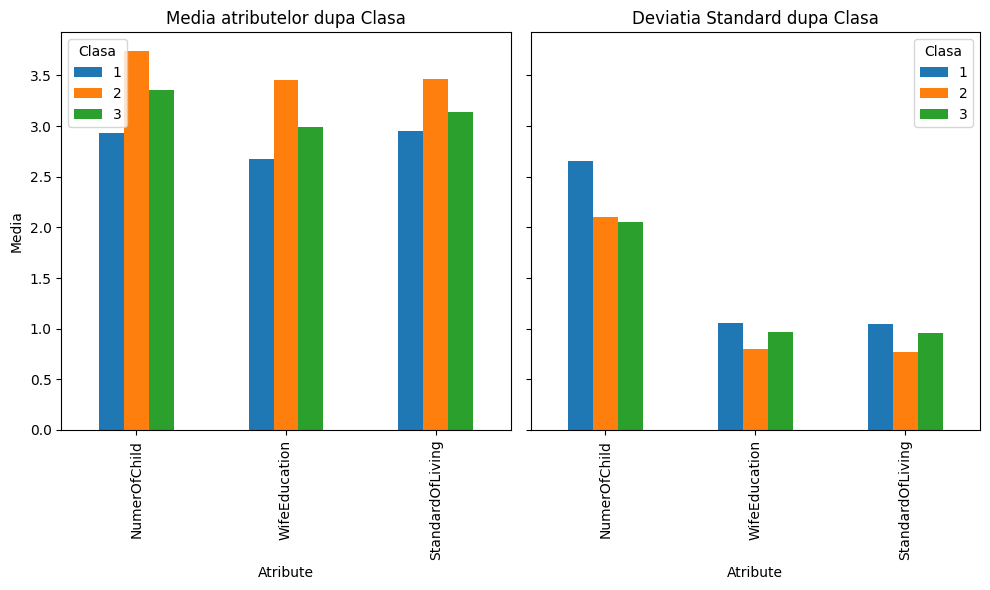

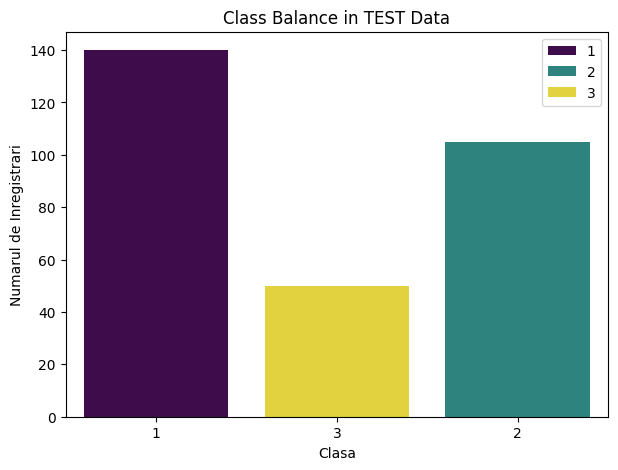

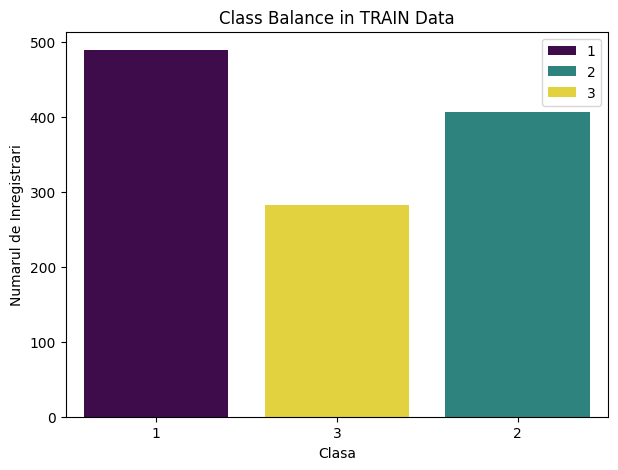

In [2]:
# Media si deviata standard
class_stats = {}
for cls in y.unique():
    class_data = X.loc[y == cls, ['NumerOfChild','WifeEducation','StandardOfLiving']] #Se pot adauga mai multe atribute pentru plotare
                                 # 'WifeAge',
    class_stats[cls] = {"mean": class_data.mean(),"std": class_data.std()}
mean_df = pd.DataFrame({cls: stats["mean"] for cls, stats in class_stats.items()})
std_df = pd.DataFrame({cls: stats["std"] for cls, stats in class_stats.items()})
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Media plot
mean_df.plot(kind="bar", ax=axes[0])
axes[0].set_title("Media atributelor dupa Clasa")
axes[0].set_ylabel("Media")
axes[0].set_xlabel("Atribute")
axes[0].legend(title="Clasa")

# Deviatia Standard plot
std_df.plot(kind="bar", ax=axes[1])
axes[1].set_title("Deviatia Standard dupa Clasa")
axes[1].set_ylabel("Deviatia Standard")
axes[1].set_xlabel("Atribute")
axes[1].legend(title="Clasa")
plt.tight_layout()

#Numarul de clase pentru fiecare set de date train/test
plt.figure(figsize=(7, 5))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette="viridis",hue=[1,2,3])
plt.title("Class Balance in TEST Data")
plt.xlabel("Clasa")
plt.ylabel("Numarul de Inregistrari")
plt.xticks(ticks=range(len(class_distribution.index)), labels=class_distribution.index)

plt.figure(figsize=(7, 5))
sns.barplot(x=class_distribution1.index, y=class_distribution1.values, palette="viridis",hue=[1,2,3])
plt.title("Class Balance in TRAIN Data")
plt.xlabel("Clasa")
plt.ylabel("Numarul de Inregistrari")
plt.xticks(ticks=range(len(class_distribution1.index)), labels=class_distribution1.index)
plt.show()


Accuracy: 0.492

Classification Report:
               precision    recall  f1-score   support

           1       0.67      0.38      0.48       140
           2       0.32      0.72      0.44        50
           3       0.55      0.53      0.54       105

    accuracy                           0.49       295
   macro avg       0.51      0.54      0.49       295
weighted avg       0.57      0.49      0.50       295



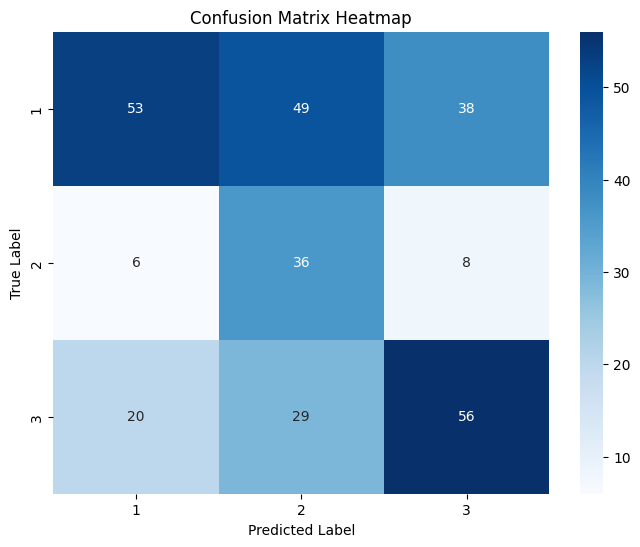

In [3]:
data = pd.read_csv("/content/cmc.csv")

# Preprocesarea
data = data.fillna(-999)
X = data.iloc[:, :-1]
y = data['ContraceptiveMethodUsed']
numerical_features = ['WifeAge', 'NumerOfChild', 'WifeEducation']

# Impartirea datelor in 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# Antrenarea modelului Gaussian default din biblioteca Sklearn
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)

# Evaluare Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)

# Matricea de confuzie
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()